<a href="https://www.kaggle.com/code/sonawanelalitsunil/adaptive-learning-personalized-education-ml-81?scriptVersionId=229216659" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/personalized-learning-and-adaptive-education-dataset/personalized_learning_dataset.csv


## Adaptive Learning & Personalized Education Dataset

This dataset captures various aspects of personalized and adaptive education systems, focusing on how learning platforms tailor content to individual students. It includes information on student demographics, learning styles, engagement metrics, assessment scores, adaptive recommendations, and course completion rates.

Key Features:

Student Data: Age, prior knowledge, learning preferences, engagement time

Learning Progress: Quiz scores, assignment submissions, topic mastery

Adaptive Features: Recommended content, difficulty adjustments, AI-driven feedback

Platform Interaction: Time spent on lessons, session frequency, dropout risk

## Import dataset

In [2]:
df = pd.read_csv('/kaggle/input/personalized-learning-and-adaptive-education-dataset/personalized_learning_dataset.csv')

In [3]:
df.head()

,Student_ID,Age,Gender,Education_Level,Course_Name,Time_Spent_on_Videos,Quiz_Attempts,Quiz_Scores,Forum_Participation,Assignment_Completion_Rate,Engagement_Level,Final_Exam_Score,Learning_Style,Feedback_Score,Dropout_Likelihood
0,S00001,15,Female,High School,Machine Learning,171,4,67,2,89,Medium,51,Visual,1,No
1,S00002,49,Male,Undergraduate,Python Basics,156,4,64,0,94,Medium,92,Reading/Writing,5,No
2,S00003,20,Female,Undergraduate,Python Basics,217,2,55,2,67,Medium,45,Reading/Writing,1,No
3,S00004,37,Female,Undergraduate,Data Science,489,1,65,43,60,High,59,Visual,4,No
4,S00005,34,Female,Postgraduate,Python Basics,496,3,59,34,88,Medium,93,Visual,3,No


In [4]:
df.tail()

,Student_ID,Age,Gender,Education_Level,Course_Name,Time_Spent_on_Videos,Quiz_Attempts,Quiz_Scores,Forum_Participation,Assignment_Completion_Rate,Engagement_Level,Final_Exam_Score,Learning_Style,Feedback_Score,Dropout_Likelihood
9995,S09996,26,Female,Undergraduate,Machine Learning,162,2,87,27,73,Medium,68,Kinesthetic,2,No
9996,S09997,37,Male,Postgraduate,Machine Learning,447,2,39,10,68,Medium,46,Reading/Writing,1,Yes
9997,S09998,40,Female,Postgraduate,Machine Learning,105,4,50,23,41,High,64,Visual,1,No
9998,S09999,44,Male,High School,Python Basics,245,2,84,39,85,Medium,38,Visual,2,No
9999,S10000,39,Female,Undergraduate,Machine Learning,171,2,88,8,69,Medium,97,Visual,2,No


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Student_ID                  10000 non-null  object
 1   Age                         10000 non-null  int64 
 2   Gender                      10000 non-null  object
 3   Education_Level             10000 non-null  object
 4   Course_Name                 10000 non-null  object
 5   Time_Spent_on_Videos        10000 non-null  int64 
 6   Quiz_Attempts               10000 non-null  int64 
 7   Quiz_Scores                 10000 non-null  int64 
 8   Forum_Participation         10000 non-null  int64 
 9   Assignment_Completion_Rate  10000 non-null  int64 
 10  Engagement_Level            10000 non-null  object
 11  Final_Exam_Score            10000 non-null  int64 
 12  Learning_Style              10000 non-null  object
 13  Feedback_Score              10000 non-null  int

In [6]:
df.describe()

,Age,Time_Spent_on_Videos,Quiz_Attempts,Quiz_Scores,Forum_Participation,Assignment_Completion_Rate,Final_Exam_Score,Feedback_Score
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,32.137700,255.375400,2.500500,64.578600,24.616200,69.546800,64.697000,3.012600
std,10.062647,141.656392,1.122642,20.289125,14.330305,17.360782,20.096417,1.421423
min,15.000000,10.000000,1.000000,30.000000,0.000000,40.000000,30.000000,1.000000
25%,24.000000,131.000000,1.000000,47.000000,12.000000,54.000000,47.000000,2.000000
50%,32.000000,257.000000,3.000000,65.000000,25.000000,69.000000,65.000000,3.000000
75%,41.000000,378.000000,4.000000,82.000000,37.000000,85.000000,82.000000,4.000000
max,49.000000,499.000000,4.000000,99.000000,49.000000,99.000000,99.000000,5.000000


In [7]:
df.isnull().sum()

Student_ID                    0
Age                           0
Gender                        0
Education_Level               0
Course_Name                   0
Time_Spent_on_Videos          0
Quiz_Attempts                 0
Quiz_Scores                   0
Forum_Participation           0
Assignment_Completion_Rate    0
Engagement_Level              0
Final_Exam_Score              0
Learning_Style                0
Feedback_Score                0
Dropout_Likelihood            0
dtype: int64

In [8]:
df.duplicated().sum()

0

In [9]:
df.corr

<bound method DataFrame.corr of      Student_ID  Age  Gender Education_Level       Course_Name  \
0        S00001   15  Female     High School  Machine Learning   
1        S00002   49    Male   Undergraduate     Python Basics   
2        S00003   20  Female   Undergraduate     Python Basics   
3        S00004   37  Female   Undergraduate      Data Science   
4        S00005   34  Female    Postgraduate     Python Basics   
...         ...  ...     ...             ...               ...   
9995     S09996   26  Female   Undergraduate  Machine Learning   
9996     S09997   37    Male    Postgraduate  Machine Learning   
9997     S09998   40  Female    Postgraduate  Machine Learning   
9998     S09999   44    Male     High School     Python Basics   
9999     S10000   39  Female   Undergraduate  Machine Learning   

      Time_Spent_on_Videos  Quiz_Attempts  Quiz_Scores  Forum_Participation  \
0                      171              4           67                    2   
1                

In [10]:
df.shape

(10000, 15)

In [11]:
df.columns

Index(['Student_ID', 'Age', 'Gender', 'Education_Level', 'Course_Name',
       'Time_Spent_on_Videos', 'Quiz_Attempts', 'Quiz_Scores',
       'Forum_Participation', 'Assignment_Completion_Rate', 'Engagement_Level',
       'Final_Exam_Score', 'Learning_Style', 'Feedback_Score',
       'Dropout_Likelihood'],
      dtype='object')

## data visualizations

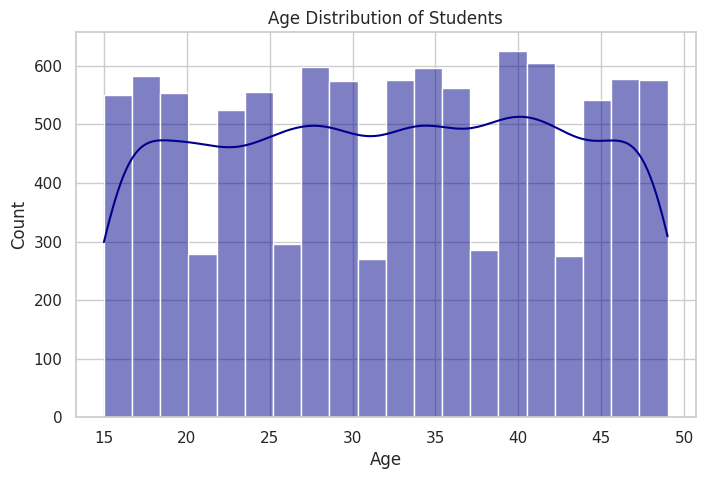

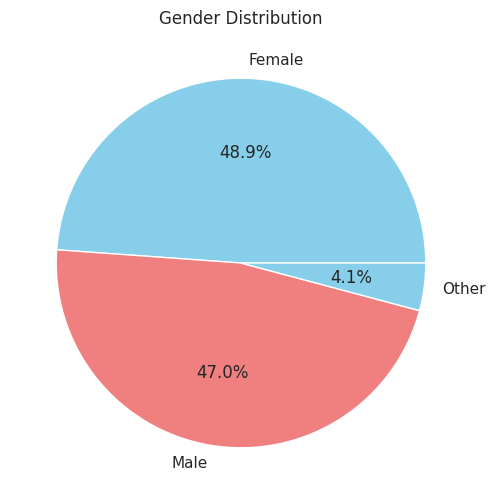

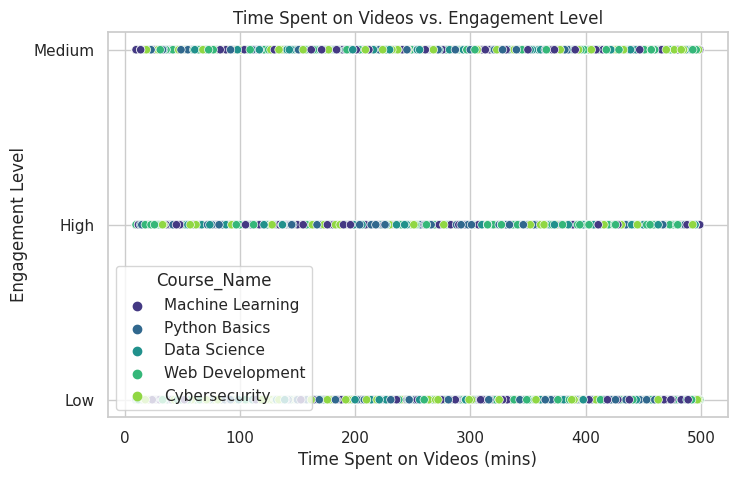

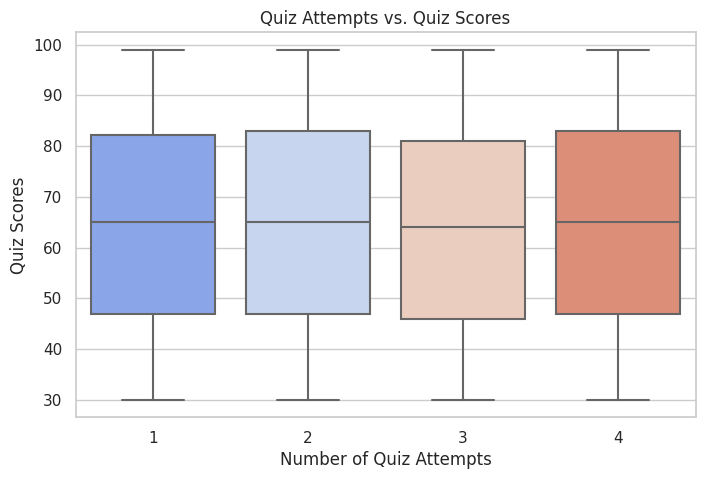

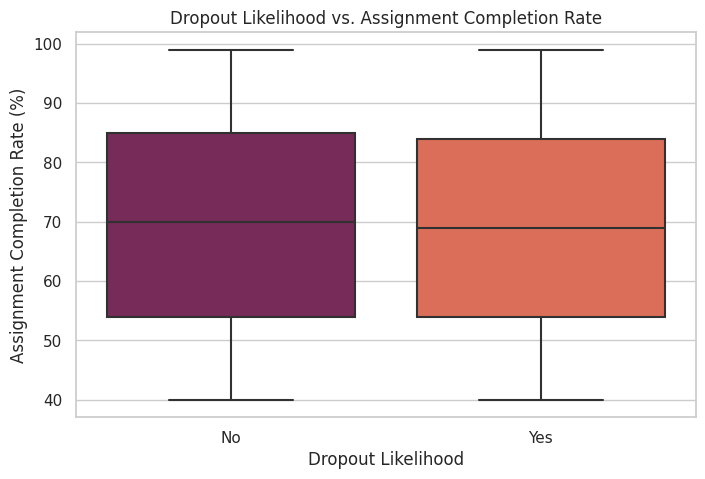

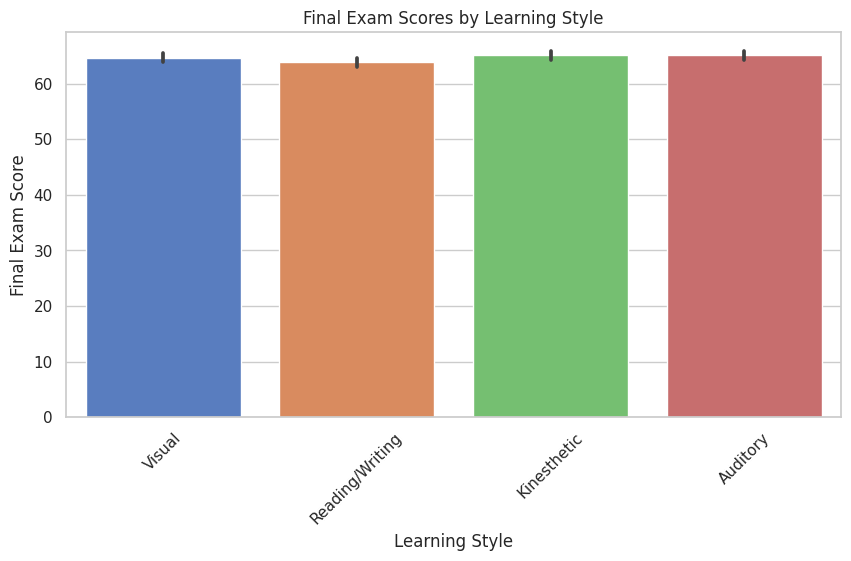

In [12]:
# Set Seaborn style
sns.set(style="whitegrid")

# 1. Age Distribution
plt.figure(figsize=(8, 5))
sns.histplot(df['Age'], bins=20, kde=True, color='darkblue')
plt.title("Age Distribution of Students")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

# 2. Gender Distribution
plt.figure(figsize=(6, 6))
df['Gender'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=["skyblue", "lightcoral"])
plt.title("Gender Distribution")
plt.ylabel("")
plt.show()

# 3. Time Spent on Videos vs. Engagement Level
plt.figure(figsize=(8, 5))
sns.scatterplot(x=df['Time_Spent_on_Videos'], y=df['Engagement_Level'], hue=df['Course_Name'], palette="viridis")
plt.title("Time Spent on Videos vs. Engagement Level")
plt.xlabel("Time Spent on Videos (mins)")
plt.ylabel("Engagement Level")
plt.show()

# 4. Quiz Attempts vs. Quiz Scores
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['Quiz_Attempts'], y=df['Quiz_Scores'], palette="coolwarm")
plt.title("Quiz Attempts vs. Quiz Scores")
plt.xlabel("Number of Quiz Attempts")
plt.ylabel("Quiz Scores")
plt.show()

# 5. Dropout Likelihood vs. Assignment Completion Rate
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['Dropout_Likelihood'], y=df['Assignment_Completion_Rate'], palette="rocket")
plt.title("Dropout Likelihood vs. Assignment Completion Rate")
plt.xlabel("Dropout Likelihood")
plt.ylabel("Assignment Completion Rate (%)")
plt.show()

# 6. Learning Style vs. Final Exam Score
plt.figure(figsize=(10, 5))
sns.barplot(x=df['Learning_Style'], y=df['Final_Exam_Score'], palette="muted")
plt.title("Final Exam Scores by Learning Style")
plt.xlabel("Learning Style")
plt.ylabel("Final Exam Score")
plt.xticks(rotation=45)
plt.show()

## Predictive visualizations

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

In [14]:
# For simplicity, select a subset of features that might influence dropout likelihood
features = ['Age', 'Time_Spent_on_Videos', 'Quiz_Attempts', 'Quiz_Scores', 'Forum_Participation', 'Assignment_Completion_Rate', 'Final_Exam_Score', 'Feedback_Score']

# Prepare target variable
target = 'Dropout_Likelihood'

In [15]:
# Encode target variable if it is categorical
le = LabelEncoder()
df[target] = le.fit_transform(df[target])

In [16]:
# Create training and testing sets
X = df[features]
y = df[target]

In [17]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [18]:
# Scale numeric features
scaler = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

In [19]:
# Define ML models
models = {
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Support Vector Machine": SVC(),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5)
}

In [20]:
# Train and evaluate models
accuracy_results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred) * 100  # Convert to percentage
    accuracy_results[name] = accuracy
    print(f"{name} Accuracy: {accuracy:.2f}%")


Logistic Regression Accuracy: 81.15%
Random Forest Accuracy: 81.05%
Support Vector Machine Accuracy: 81.15%
K-Nearest Neighbors Accuracy: 78.10%


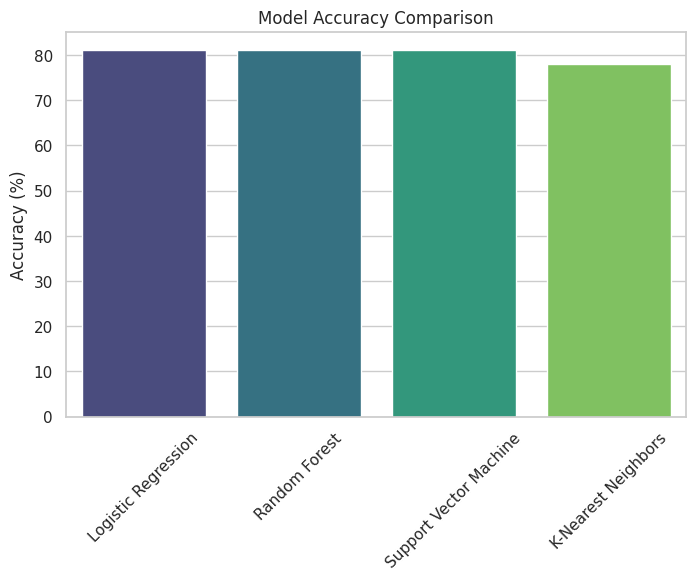

In [21]:
# Show accuracy results
plt.figure(figsize=(8, 5))
sns.barplot(x=list(accuracy_results.keys()), y=list(accuracy_results.values()), palette="viridis")
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy (%)")
plt.xticks(rotation=45)
plt.show()


## Thank you..pls upvote!!!